# Patient Health Records — Data Cleaning & Analysis

**Dataset:** `healthcare_dataset.csv` (500 patient records, 10 fields)

This notebook covers:
1. Data Cleaning
2. Missing Value Handling
3. Outlier Detection (IQR)
4. BMI Analysis
5. Cholesterol Analysis
6. Blood Pressure Analysis
7. Correlation Analysis
8. Age Group Feature Engineering


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

df = pd.read_csv("healthcare_dataset.csv")
df.head()

,Patient_ID,Age,Gender,Blood_Pressure,Heart_Rate,Cholesterol_Level,BMI,Diagnosis,Treatment_Plan,Follow_Up_Date
0,1,51,Female,97,90,282,35.2,Hypertension,Observation,2024-01-01
1,2,92,Other,129,80,169,32.3,Healthy,Medication,2024-01-02
2,3,14,Male,172,76,157,29.9,Diabetes,Observation,2024-01-03
3,4,71,Female,131,82,150,19.4,Coronary Artery Disease,Surgery,2024-01-04
4,5,60,Male,130,96,206,39.3,Diabetes,NaN,2024-01-05


## 1. Data Cleaning

Inspect shape, data types, and check for duplicate rows or messy string formatting.

In [2]:
print("Shape:", df.shape)
df.dtypes

Shape: (500, 10)


Patient_ID             int64
Age                    int64
Gender                   str
Blood_Pressure         int64
Heart_Rate             int64
Cholesterol_Level      int64
BMI                  float64
Diagnosis                str
Treatment_Plan           str
Follow_Up_Date           str
dtype: object

In [3]:
# Check for duplicate rows
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")
df = df.drop_duplicates()

# Strip whitespace from string columns
str_cols = df.select_dtypes(include="object").columns
for c in str_cols:
    df[c] = df[c].astype(str).str.strip()

print("Shape after cleaning:", df.shape)
df.head()

Duplicate rows: 0
Shape after cleaning: (500, 10)


/tmp/ipykernel_577/3392163168.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns


,Patient_ID,Age,Gender,Blood_Pressure,Heart_Rate,Cholesterol_Level,BMI,Diagnosis,Treatment_Plan,Follow_Up_Date
0,1,51,Female,97,90,282,35.2,Hypertension,Observation,2024-01-01
1,2,92,Other,129,80,169,32.3,Healthy,Medication,2024-01-02
2,3,14,Male,172,76,157,29.9,Diabetes,Observation,2024-01-03
3,4,71,Female,131,82,150,19.4,Coronary Artery Disease,Surgery,2024-01-04
4,5,60,Male,130,96,206,39.3,Diabetes,NaN,2024-01-05


## 2. Missing Value Handling

Identify columns with missing data and impute: **median** for numeric columns, **mode** for categorical columns.

In [4]:
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})[missing > 0]

,missing_count,missing_pct
Treatment_Plan,95,19.0


In [5]:
numeric_cols = ["Age", "Blood_Pressure", "Heart_Rate", "Cholesterol_Level", "BMI"]
categorical_cols = ["Gender", "Diagnosis", "Treatment_Plan"]

for c in numeric_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

for c in categorical_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].mode()[0])

print("Remaining missing values:", df.isna().sum().sum())

Remaining missing values: 0


## 3. Outlier Detection (IQR Method)

For each numeric column: flag values outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.

In [6]:
outlier_summary = {}
outlier_mask_total = pd.Series(False, index=df.index)

for c in numeric_cols:
    Q1, Q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask = (df[c] < lower) | (df[c] > upper)
    outlier_mask_total |= mask
    outlier_summary[c] = {"Q1": Q1, "Q3": Q3, "IQR": IQR, "lower_bound": lower, "upper_bound": upper, "n_outliers": int(mask.sum())}

df["Is_Outlier"] = outlier_mask_total
outlier_df = pd.DataFrame(outlier_summary).T.round(2)
outlier_df

,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers
Age,23.00,72.25,49.25,-50.88,146.12,0.0
Blood_Pressure,112.00,154.00,42.00,49.00,217.00,0.0
Heart_Rate,70.75,90.00,19.25,41.88,118.88,0.0
Cholesterol_Level,186.00,267.00,81.00,64.50,388.50,0.0
BMI,24.10,34.72,10.62,8.16,50.66,0.0


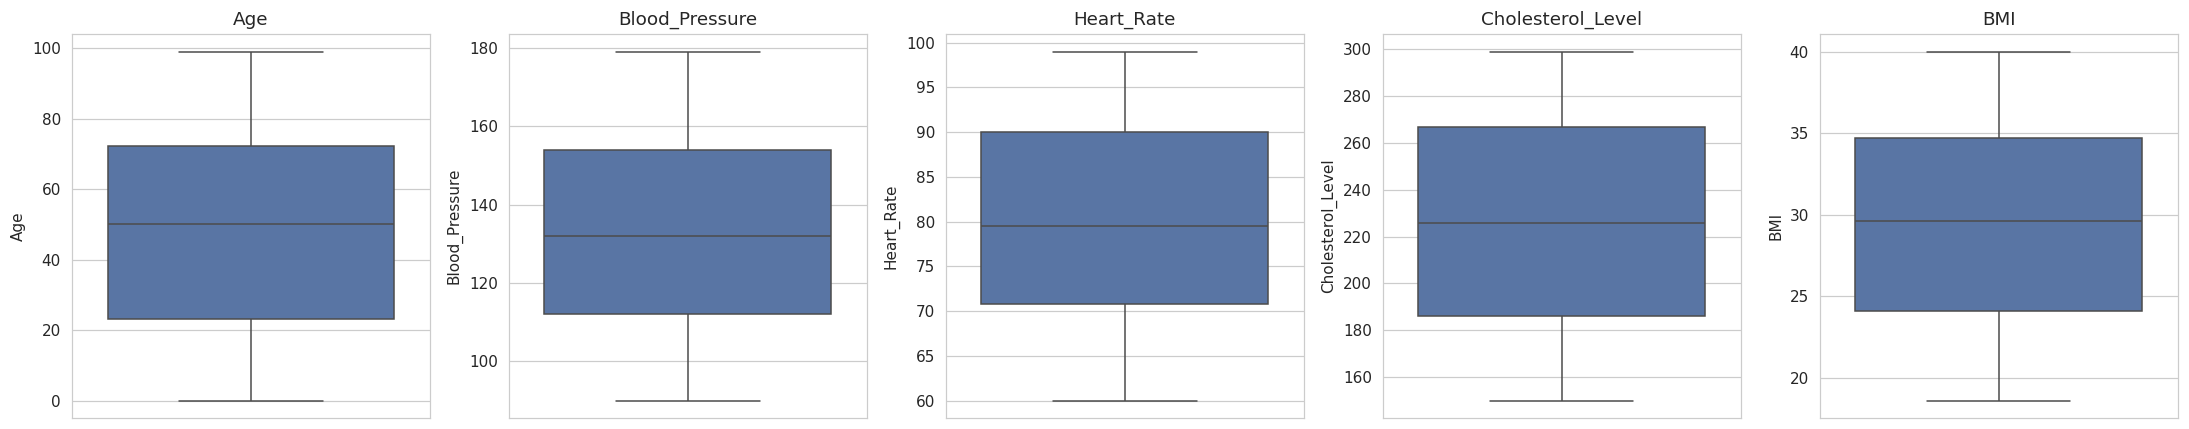

Rows flagged as outliers on at least one metric: 0 (0.0% of records)


In [7]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4 * len(numeric_cols), 4))
for ax, c in zip(axes, numeric_cols):
    sns.boxplot(y=df[c], ax=ax, color="#4C72B0")
    ax.set_title(c)
plt.tight_layout()
plt.show()

print(f"Rows flagged as outliers on at least one metric: {int(outlier_mask_total.sum())} "
      f"({outlier_mask_total.mean()*100:.1f}% of records)")

## 4. BMI Analysis

Categorize BMI using WHO standard bands: Underweight (<18.5), Normal (18.5–25), Overweight (25–30), Obese (30+).

In [8]:
def bmi_category(b):
    if b < 18.5: return "Underweight"
    elif b < 25: return "Normal"
    elif b < 30: return "Overweight"
    else: return "Obese"

df["BMI_Category"] = df["BMI"].apply(bmi_category)
display(df["BMI"].describe().round(2))
df["BMI_Category"].value_counts()

count    500.00
mean      29.43
std        6.13
min       18.60
25%       24.10
50%       29.60
75%       34.72
max       40.00
Name: BMI, dtype: float64

BMI_Category
Obese         242
Normal        147
Overweight    111
Name: count, dtype: int64

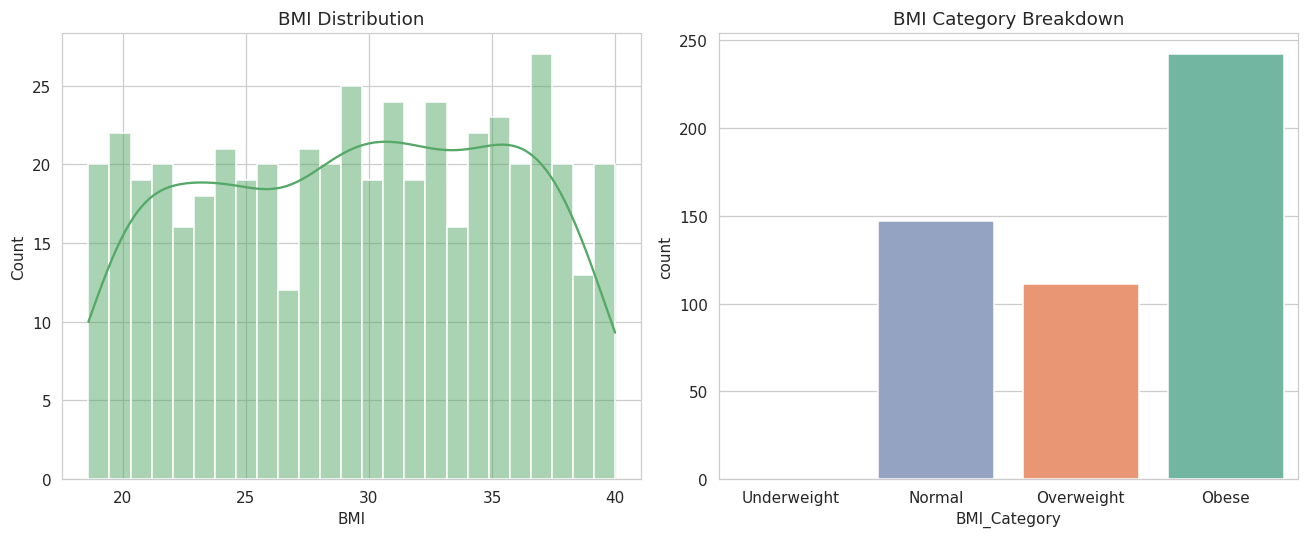

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df["BMI"], bins=25, kde=True, ax=axes[0], color="#55A868")
axes[0].set_title("BMI Distribution")

order = ["Underweight", "Normal", "Overweight", "Obese"]
sns.countplot(data=df, x="BMI_Category", order=order, hue="BMI_Category", legend=False, palette="Set2", ax=axes[1])
axes[1].set_title("BMI Category Breakdown")
plt.tight_layout()
plt.show()

## 5. Cholesterol Analysis

Categorize cholesterol level: Desirable (<200), Borderline High (200–239), High (240+).

In [10]:
def chol_category(c):
    if c < 200: return "Desirable"
    elif c < 240: return "Borderline High"
    else: return "High"

df["Cholesterol_Category"] = df["Cholesterol_Level"].apply(chol_category)
display(df["Cholesterol_Level"].describe().round(2))
df["Cholesterol_Category"].value_counts()

count    500.00
mean     225.81
std       44.96
min      150.00
25%      186.00
50%      226.00
75%      267.00
max      299.00
Name: Cholesterol_Level, dtype: float64

Cholesterol_Category
High               202
Desirable          170
Borderline High    128
Name: count, dtype: int64

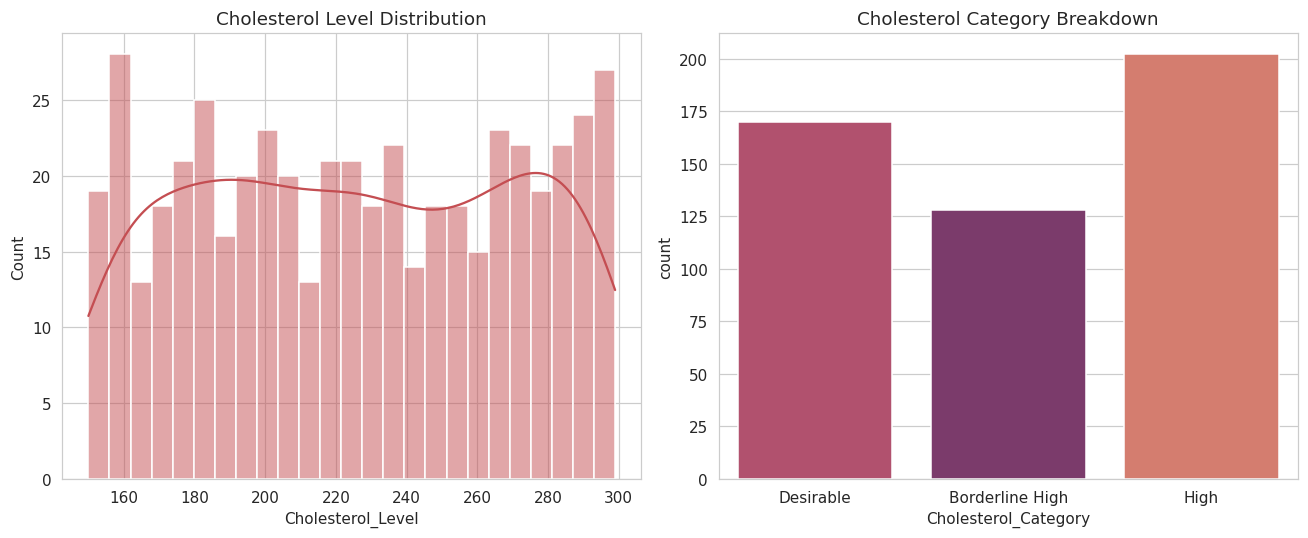

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df["Cholesterol_Level"], bins=25, kde=True, ax=axes[0], color="#C44E52")
axes[0].set_title("Cholesterol Level Distribution")

order_c = ["Desirable", "Borderline High", "High"]
sns.countplot(data=df, x="Cholesterol_Category", order=order_c, hue="Cholesterol_Category", legend=False, palette="flare", ax=axes[1])
axes[1].set_title("Cholesterol Category Breakdown")
plt.tight_layout()
plt.show()

## 6. Blood Pressure Analysis

Categorize blood pressure: Low (<90), Normal (90–119), Elevated (120–139), High (140+).

In [12]:
def bp_category(b):
    if b < 90: return "Low"
    elif b < 120: return "Normal"
    elif b < 140: return "Elevated"
    else: return "High"

df["BP_Category"] = df["Blood_Pressure"].apply(bp_category)
display(df["Blood_Pressure"].describe().round(2))
df["BP_Category"].value_counts()

count    500.00
mean     133.02
std       25.67
min       90.00
25%      112.00
50%      132.00
75%      154.00
max      179.00
Name: Blood_Pressure, dtype: float64

BP_Category
High        215
Normal      171
Elevated    114
Name: count, dtype: int64

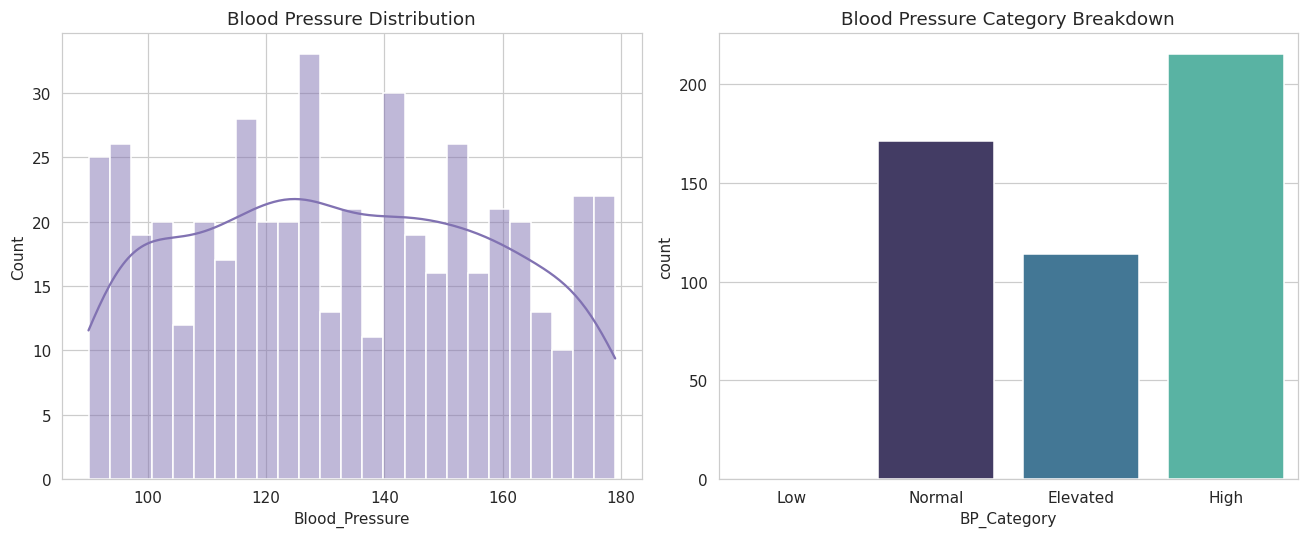

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df["Blood_Pressure"], bins=25, kde=True, ax=axes[0], color="#8172B2")
axes[0].set_title("Blood Pressure Distribution")

order_bp = ["Low", "Normal", "Elevated", "High"]
sns.countplot(data=df, x="BP_Category", order=order_bp, hue="BP_Category", legend=False, palette="mako", ax=axes[1])
axes[1].set_title("Blood Pressure Category Breakdown")
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

Pearson correlation across all numeric health metrics.

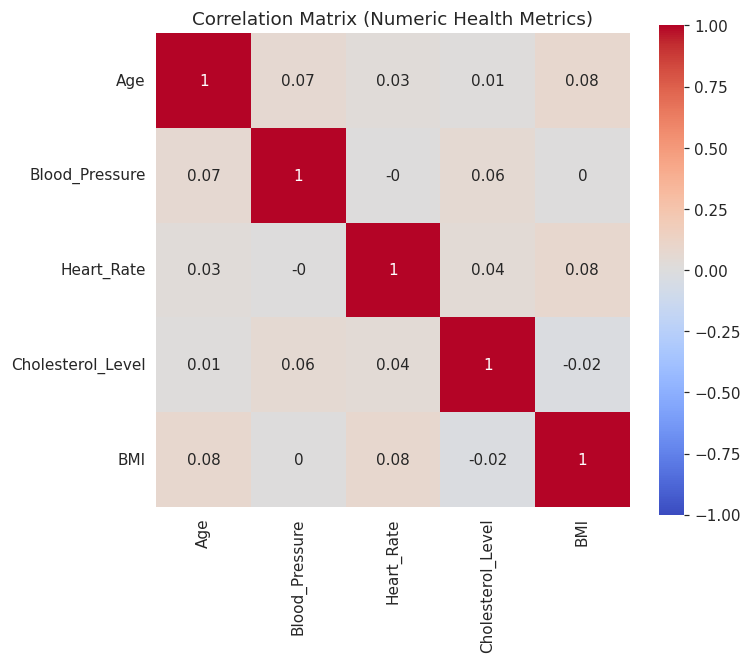

,Age,Blood_Pressure,Heart_Rate,Cholesterol_Level,BMI
Age,1.00,0.07,0.03,0.01,0.08
Blood_Pressure,0.07,1.00,-0.00,0.06,0.00
Heart_Rate,0.03,-0.00,1.00,0.04,0.08
Cholesterol_Level,0.01,0.06,0.04,1.00,-0.02
BMI,0.08,0.00,0.08,-0.02,1.00


In [14]:
corr = df[numeric_cols].corr().round(2)
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix (Numeric Health Metrics)")
plt.tight_layout()
plt.show()

corr

All pairwise correlations are close to zero, indicating no meaningful linear relationship between Age, Blood Pressure, Heart Rate, Cholesterol, and BMI in this dataset — each metric behaves largely independently of the others.

## 8. Age Group Feature Engineering

Bin the continuous `Age` variable into clinically meaningful life-stage segments.

In [15]:
bins = [0, 12, 19, 35, 50, 65, 120]
labels = ["Child (0-12)", "Teen (13-19)", "Young Adult (20-35)", "Adult (36-50)", "Middle Age (51-65)", "Senior (66+)"]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True, include_lowest=True)

df["Age_Group"].value_counts().reindex(labels)

Age_Group
Child (0-12)            67
Teen (13-19)            39
Young Adult (20-35)     82
Adult (36-50)           65
Middle Age (51-65)      93
Senior (66+)           154
Name: count, dtype: int64

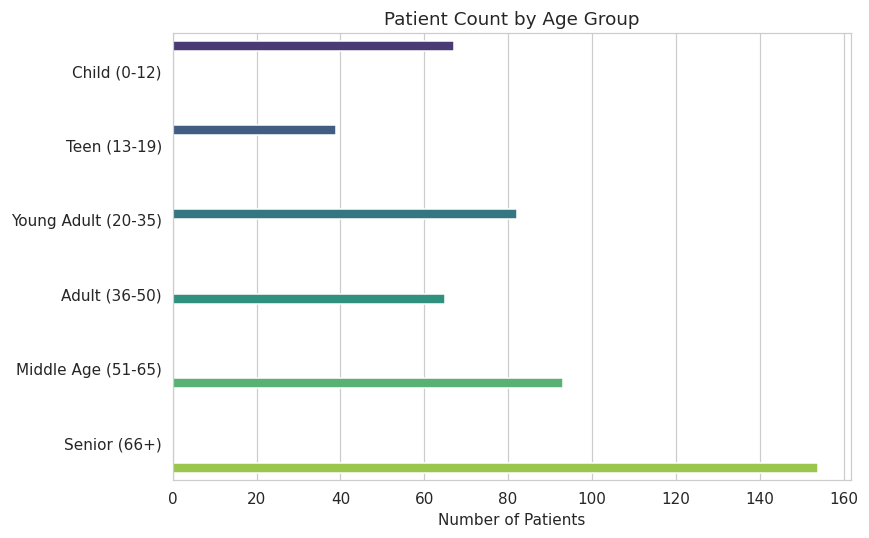

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, y="Age_Group", order=labels, hue="Age_Group", legend=False, palette="viridis")
plt.title("Patient Count by Age Group")
plt.xlabel("Number of Patients")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Save Cleaned Dataset

In [17]:
df.to_csv("cleaned_healthcare_dataset.csv", index=False)
print("Saved cleaned_healthcare_dataset.csv —", df.shape)
df.head()

Saved cleaned_healthcare_dataset.csv — (500, 15)


,Patient_ID,Age,Gender,Blood_Pressure,Heart_Rate,Cholesterol_Level,BMI,Diagnosis,Treatment_Plan,Follow_Up_Date,Is_Outlier,BMI_Category,Cholesterol_Category,BP_Category,Age_Group
0,1,51,Female,97,90,282,35.2,Hypertension,Observation,2024-01-01,False,Obese,High,Normal,Middle Age (51-65)
1,2,92,Other,129,80,169,32.3,Healthy,Medication,2024-01-02,False,Obese,Desirable,Elevated,Senior (66+)
2,3,14,Male,172,76,157,29.9,Diabetes,Observation,2024-01-03,False,Overweight,Desirable,High,Teen (13-19)
3,4,71,Female,131,82,150,19.4,Coronary Artery Disease,Surgery,2024-01-04,False,Normal,Desirable,Elevated,Senior (66+)
4,5,60,Male,130,96,206,39.3,Diabetes,Medication,2024-01-05,False,Obese,Borderline High,Elevated,Middle Age (51-65)
